# Fine-tuning Stable Diffusion 2.1 con VAE adattato al dominio mammografico

Questo notebook estende `02_SD21_Filtered_100steps.ipynb` aggiungendo, come primo stadio, il **fine-tuning del VAE di Stable Diffusion 2.1** sulle mammografie preprocessate (Domanda di ricerca **D5** del README).

L'ipotesi e' che il VAE pre-addestrato su ImageNet RGB perda dettagli specifici del tessuto mammografico durante la fase di ricostruzione. Adattando il decoder al dominio, ci si aspetta:

- una riduzione delle metriche di ricostruzione (L1 / LPIPS) e un miglioramento del PSNR;
- un miglioramento di FID / PRDC dopo la fase di fine-tuning della U-Net, poiche' la U-Net apprende una distribuzione di latenti coerente con un decoder gia' adattato al dominio;
- un potenziale beneficio sui classificatori a valle, valutato indirettamente tramite le pipeline gia' esistenti.

Pipeline (equivalente estesa di `03b`):

1. verifica e preparazione dei dati (identica a `03b`);
2. **fine-tuning del VAE di SD2.1** sul training set (real + augmented) — solo decoder di default;
3. costruzione di una copia dell'SD2.1 base con VAE sostituito dal fine-tuned;
4. fine-tuning della U-Net su questa base con **checkpoint piu' frequenti** e piu' step totali;
5. selezione del checkpoint sul validation set (FID + PRDC);
6. generazione RAW a 100 inference step, dataset RAW matched, filtro adattivo;
7. confronto RAW / filtrate sul validation set;
8. valutazione finale sul test set;
9. confronto tra la pipeline `03b` (VAE congelato) e la presente `03c` (VAE adattato).

**Cartelle dedicate:**

- esperimento: `experiments/diffusers/03_sd21_vae_finetuned/`
- risultati: `results/diffusers/03_sd21_vae_finetuned/`
- immagini sintetiche finali filtrate: `data/synthetic/fine_tuned_vaeft/{positive, negative}/`

**Nota metodologica:** il fine-tuning del VAE viene calibrato con L1 + LPIPS (se disponibile) sulle mammografie in scala di grigi replicate su 3 canali, mantenendo la stessa `scaling_factor` (0.18215). Il decoder-only training preserva la distribuzione dei latenti attesa dalla U-Net; e' comunque possibile scongelare l'encoder passando l'argomento `--full-vae` allo script.

## 1. Ambiente e configurazione

Le celle seguenti impostano l'ambiente di esecuzione, individuano la root del progetto, verificano PyTorch/GPU e definiscono una **singola configurazione condivisa** dall'intero notebook (cartelle esperimento e risultati dedicate, parametri di training del VAE e della U-Net, parametri di valutazione e generazione).

Rispetto a `03b`:

- `EXPERIMENT_NAME` e `RESULTS_03C_DIR` sono nuovi e isolano gli artefatti da quelli precedenti;
- viene aggiunta una configurazione dedicata al fine-tuning del VAE (`VAE_*`), con LPIPS attivo, early stopping e log persistente del subprocess;
- `CHECKPOINTING_STEPS` scende a **250** e `MAX_TRAIN_STEPS` sale a **12000**, come richiesto (checkpoint piu' frequenti + orizzonte piu' lungo);
- il modello base viene duplicato in `pretrained_model_vaeft/` con il decoder aggiornato prima del training della U-Net.

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

# Bootstrap dipendenze e import (equivalente 03b, EXPERIMENT_NAME/RESULTS aggiornati per 03c)
from pathlib import Path
from tempfile import TemporaryDirectory
from datetime import datetime
from contextlib import contextmanager
import gc
import hashlib
import importlib
import importlib.util
import json
import math
import os
import re
import shutil
import subprocess
import sys
import warnings
import zipfile

PROJECT_NAME = "MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None  # Esempio Colab: "/content/drive/MyDrive/MammoDiffusion"
EXPERIMENT_NAME = "diffusers/03_sd21_vae_finetuned"
DIFFUSERS_REVISION = "3759fab56d3170a04d747e918a13e55fda6681e2"


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.is_dir():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        has_notebooks = (candidate / "notebooks").is_dir() or (candidate / "notebooks").is_dir()
        if candidate.name == project_name or ((candidate / "data").is_dir() and has_notebooks) or ((candidate / ".git").exists() and has_notebooks):
            return candidate
    fallback_candidates = [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
        Path.home() / "Progetto" / project_name,
    ]
    for candidate in fallback_candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Root di MammoDiffusion non trovata. Esegui il notebook dalla repository "
        "oppure imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
NOTEBOOKS_DIR = PROJECT_ROOT / ("notebooks" if (PROJECT_ROOT / "notebooks").is_dir() else "notebooks")
UTILITY_DIR = NOTEBOOKS_DIR / "utility" if (NOTEBOOKS_DIR / "utility").is_dir() else NOTEBOOKS_DIR
for _path in (UTILITY_DIR, NOTEBOOKS_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
EXPERIMENT_DIR = EXPERIMENTS_DIR / EXPERIMENT_NAME
DIFFUSERS_REPO_DIR = EXPERIMENT_DIR / "diffusers_repo"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

AUTO_INSTALL_PACKAGES = {
    "gdown": "gdown",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "Pillow",
    "tqdm": "tqdm",
    "IPython": "ipython",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "datasets": "datasets",
    "safetensors": "safetensors",
    "huggingface_hub": "huggingface_hub",
    "bitsandbytes": "bitsandbytes",
    "prdc": "prdc",
    "tensorboard": "tensorboard",
    "lpips": "lpips",  # necessario per il fine-tuning percettivo del VAE
}
missing_packages = [
    package_name
    for module_name, package_name in AUTO_INSTALL_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

missing_required = [
    module_name for module_name in ["torch"] if importlib.util.find_spec(module_name) is None
]
if missing_required:
    raise ImportError(
        "Dipendenze richieste non trovate: " + ", ".join(missing_required)
        + ". Installa PyTorch nell'ambiente prima di eseguire il notebook."
    )

if not (DIFFUSERS_REPO_DIR / ".git").is_dir():
    subprocess.run(
        ["git", "clone", "https://github.com/huggingface/diffusers", str(DIFFUSERS_REPO_DIR)],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(DIFFUSERS_REPO_DIR), "checkout", DIFFUSERS_REVISION],
        check=True,
    )

TRAIN_SCRIPT = DIFFUSERS_REPO_DIR / "examples" / "text_to_image" / "train_text_to_image.py"
if not TRAIN_SCRIPT.is_file():
    raise FileNotFoundError(f"Script di training non trovato: {TRAIN_SCRIPT}")

current_revision = subprocess.check_output(
    [
        "git",
        "-c", f"safe.directory={DIFFUSERS_REPO_DIR}",
        "-C", str(DIFFUSERS_REPO_DIR),
        "rev-parse", "HEAD",
    ],
    text=True,
).strip()
if current_revision != DIFFUSERS_REVISION:
    print(f"ATTENZIONE: Diffusers e' a {current_revision}, atteso {DIFFUSERS_REVISION}.")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(DIFFUSERS_REPO_DIR)])
DIFFUSERS_SRC_DIR = DIFFUSERS_REPO_DIR / "src"
if str(DIFFUSERS_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(DIFFUSERS_SRC_DIR))
importlib.invalidate_caches()

for name in [
    "HF_HUB_VERBOSITY", "TRANSFORMERS_VERBOSITY", "DIFFUSERS_VERBOSITY", "ACCELERATE_LOG_LEVEL",
]:
    os.environ[name] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONWARNINGS"] = "ignore"

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from diffusers import AutoencoderKL, StableDiffusionPipeline, UNet2DConditionModel
from generative_evaluator import GenerativeEvaluator
from eco_tracker import measure_sustainability
from IPython.display import display
from matplotlib.patches import Patch
from PIL import Image
from prdc import compute_prdc
from tensorboard.backend.event_processing import event_accumulator
from tqdm.auto import tqdm

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA disponibile:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "nessuna")
print("PROJECT_ROOT:", PROJECT_ROOT)

bitsandbytes library load error: libnvJitLink.so.13: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 298, in get_native_library
    dll = ct.cdll.LoadLibrary(str(binary_path))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/ctypes/__init__.py", line 454, in LoadLibrary
    return self._dlltype(name)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: libnvJitLink.so.13: cannot open shared object file: No such file or directory


Python: /home/fede/miniforge3/envs/tf-gpu/bin/python
PyTorch: 2.12.0+cu130
CUDA disponibile: True
GPU: NVIDIA GeForce RTX 5060 Ti
PROJECT_ROOT: /mnt/MammoDiffusion/MammoDiffusion


In [2]:
# Dataset condivisi dal progetto e configurazione dedicata a 03c
DATA_DIR = PROJECT_ROOT / "data"
ARCHIVES_DIR = DATA_DIR / "archives"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
DATA_AUG = DATA_DIR / "real_augmented"

PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
AUGMENTED_DRIVE_ID = "1XRc0SxLEPP-zbMJApn4ruaiH8u_rDc-0"
PROCESSED_ZIP_PATH = ARCHIVES_DIR / "processed.zip"
AUGMENTED_ZIP_PATH = ARCHIVES_DIR / "real_augmented.zip"

SD21_MODEL_DRIVE_ID = "10XRn-bxpp7tP6ROWLYpeCNYJZIaHfMUt"
SHARED_PRETRAINED_ROOT = NOTEBOOKS_DIR / "pretrained_model"
PRETRAINED_MODEL_DIR = SHARED_PRETRAINED_ROOT / "stable-diffusion-2-1-base"
PRETRAINED_MODEL_ZIP_PATH = SHARED_PRETRAINED_ROOT / "archives" / "stable-diffusion-2-1-base.zip"
PRETRAINED_MODEL_VAEFT_DIR = EXPERIMENT_DIR / "pretrained_model_vaeft" / "stable-diffusion-2-1-base"
FORCE_MODEL_REDOWNLOAD = False

HF_CACHE_DIR = EXPERIMENT_DIR / "hf_cache"
SD_OUTPUT_DIR = EXPERIMENT_DIR / "model"
VAE_FT_DIR = EXPERIMENT_DIR / "vae_finetuning"
VAE_FT_SCRIPT = UTILITY_DIR / "train_sd_vae_finetune.py"
if not VAE_FT_SCRIPT.is_file():
    raise FileNotFoundError(f"Script fine-tuning VAE non trovato: {VAE_FT_SCRIPT}")

POSITIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer positive, malignant finding, "
    "suspicious lesion, medical imaging"
)
NEGATIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer negative, no malignant finding, "
    "normal screening mammogram, medical imaging"
)

# Fine-tuning VAE (nuovo rispetto a 03b)
# Config corretta dopo OOM: micro-batch 2 + gradient accumulation 2 = batch effettivo 4.
# LPIPS resta attivo a 0.1; viene calcolato in fp32 anche con mixed precision fp16.
VAE_EPOCHS = 30                    # tetto massimo; l'early stopping puo' fermare prima
VAE_BATCH_SIZE = 4                 # micro-batch reale in VRAM
VAE_GRADIENT_ACCUMULATION_STEPS = 1 # batch effettivo = 1 * 4 = 4
VAE_LEARNING_RATE = 1e-5
VAE_L1_WEIGHT = 1.0
VAE_LPIPS_WEIGHT = 0.1             # resta attivo, non azzerato
VAE_KL_WEIGHT = 0.0                # decoder-only: KL non calcolata
VAE_DECODER_ONLY = True
VAE_CHECKPOINT_EVERY_EPOCHS = 2
VAE_EARLY_STOPPING_PATIENCE = 5
VAE_EARLY_STOPPING_MIN_DELTA = 1e-4
VAE_MIN_EPOCHS = 6
VAE_ALLOW_LPIPS_FALLBACK = False    # False = se LPIPS non carica, errore esplicito invece di ignorarlo
VAE_SEED = 42
VAE_MIXED_PRECISION = "fp16"
FORCE_VAE_RETRAIN = False

# Fine-tuning U-Net (checkpoint piu' frequenti e orizzonte piu' lungo rispetto a 03b)
RESOLUTION = 512
TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-5
MAX_TRAIN_STEPS = 12000     # 03b: 8000  -> 03c: 12000 (VAE cambiato, latenti diversi)
CHECKPOINTING_STEPS = 250   # 03b: 500   -> 03c: 250   (piu' checkpoint per selezione fine)
CHECKPOINTS_TOTAL_LIMIT = 60
RESUME_FROM_CHECKPOINT = "latest"
TRAIN_SEED = 42

# Valutazione e generazione (identiche a 03b, cartelle dedicate)
N_EVAL_IMAGES_PER_CLASS = 100
N_VALIDATION_IMAGES_PER_CLASS = 73
N_TEST_IMAGES_PER_CLASS = 73
INFERENCE_STEPS = 100
EVAL_GUIDANCE_SCALE = 7.5
EVAL_SEED = 42
PRDC_NEAREST_K = 5
N_FINAL_IMAGES_PER_CLASS = 2722
FINAL_GENERATE_CLASSES = ["positive", "negative"]
N_SELECTED_PER_CLASS = 1361
RAW_MATCHED_SEED = 42
RAW_MATCHED_COUNT = N_SELECTED_PER_CLASS
RAW_MATCHED_ROOT = EXPERIMENT_DIR / "generated_images" / "raw_matched_1361"
NONBLACK_THRESHOLD = 10
FORCE_RECOMPUTE_VALIDATION_COMPARISON = False
FORCE_RECOMPUTE_FINAL_TEST = False

VALIDATION_METADATA_PATH = DATA_PROCESSED_DIR / "metadata" / "val.csv"
TEST_METADATA_PATH = DATA_PROCESSED_DIR / "metadata" / "test.csv"
TRAIN_METADATA_PATH = DATA_PROCESSED_DIR / "metadata" / "train.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_03C_DIR = RESULTS_DIR / "diffusers/03_sd21_vae_finetuned"
METRICS_DIR = RESULTS_03C_DIR / "metrics"
PLOTS_DIR = RESULTS_03C_DIR / "plots"
ECOTRACKER_DIR = RESULTS_03C_DIR / "ecotracker"
VAE_PLOTS_DIR = PLOTS_DIR / "vae_finetuning"
VAE_METRICS_DIR = METRICS_DIR / "vae_finetuning"

EVAL_DIR = EXPERIMENT_DIR / "eval_checkpoints"
EVAL_METRICS_PATH = METRICS_DIR / "checkpoint_validation_metrics.json"
EVAL_SUSTAINABILITY_LOG = ECOTRACKER_DIR / "sustainability_validation.jsonl"

FINAL_GEN_DIR = EXPERIMENT_DIR / "generated_images" / "final"
FINAL_NEG_DIR = FINAL_GEN_DIR / "negative"
FINAL_POS_DIR = FINAL_GEN_DIR / "positive"
FINAL_DIRS = {"negative": FINAL_NEG_DIR, "positive": FINAL_POS_DIR}
FINAL_CLASS_LABELS = {"negative": 0, "positive": 1}
RAW_MATCHED_DIRS = {
    class_name: RAW_MATCHED_ROOT / class_name for class_name in FINAL_GENERATE_CLASSES
}
RAW_MATCHED_MANIFEST_PATHS = {
    class_name: RAW_MATCHED_ROOT / f"{class_name}_manifest.json"
    for class_name in FINAL_GENERATE_CLASSES
}

SYNTHETIC_DIR = DATA_DIR / "synthetic"
SYNTHETIC_VAEFT_DIR = SYNTHETIC_DIR / "fine_tuned_vaeft"
FILTERED_DIRS = {
    class_name: SYNTHETIC_VAEFT_DIR / class_name for class_name in FINAL_GENERATE_CLASSES
}
FILTER_REPORT_PATHS = {
    class_name: METRICS_DIR / f"filter_report_{class_name}_adaptive_mask.csv"
    for class_name in FINAL_GENERATE_CLASSES
}
FILTER_SUMMARY_PATHS = {
    class_name: METRICS_DIR / f"filter_summary_{class_name}_adaptive_mask.json"
    for class_name in FINAL_GENERATE_CLASSES
}

VALIDATION_COMPARISON_CSV = METRICS_DIR / "validation_comparison_100_steps_raw_matched_vs_filtered.csv"
VALIDATION_COMPARISON_JSON = METRICS_DIR / "validation_comparison_100_steps_raw_matched_vs_filtered.json"
FINAL_TEST_METRICS_PATH = METRICS_DIR / "final_test_metrics.json"
FINAL_TEST_METRICS_CSV = METRICS_DIR / "final_test_metrics.csv"
FINAL_TEST_RAW_MATCHED_METRICS_PATH = METRICS_DIR / "final_test_metrics_raw_matched_100_steps.json"
FINAL_TEST_RAW_MATCHED_METRICS_CSV = METRICS_DIR / "final_test_metrics_raw_matched_100_steps.csv"

SUSTAINABILITY_LOG = ECOTRACKER_DIR / "sustainability_finetuning.jsonl"
VAE_SUSTAINABILITY_LOG = ECOTRACKER_DIR / "sustainability_vae_finetuning.jsonl"
FINAL_GENERATION_LOG = ECOTRACKER_DIR / "sustainability_generation.jsonl"
GENERATION_INFO_PATH = METRICS_DIR / "generation_info.json"
ARTIFACTS_MANIFEST_PATH = RESULTS_03C_DIR / "artifacts_manifest.json"

for directory in [
    ARCHIVES_DIR, DATA_AUG, EXPERIMENT_DIR,
    PRETRAINED_MODEL_ZIP_PATH.parent, HF_CACHE_DIR, SD_OUTPUT_DIR, EVAL_DIR,
    METRICS_DIR, PLOTS_DIR, ECOTRACKER_DIR,
    VAE_FT_DIR, VAE_PLOTS_DIR, VAE_METRICS_DIR,
    PRETRAINED_MODEL_VAEFT_DIR.parent,
    FINAL_NEG_DIR, FINAL_POS_DIR, RAW_MATCHED_ROOT,
    *RAW_MATCHED_DIRS.values(),
    SYNTHETIC_VAEFT_DIR, *FILTERED_DIRS.values(),
]:
    directory.mkdir(parents=True, exist_ok=True)


def label_to_prompt(label):
    prompts = {0: NEGATIVE_PROMPT, 1: POSITIVE_PROMPT}
    try:
        return prompts[int(label)]
    except KeyError as exc:
        raise ValueError(f"Label non valida: {label}") from exc


print("Esperimento          :", EXPERIMENT_NAME)
print("Cartella esperimento :", EXPERIMENT_DIR)
print("Cartella risultati 3c:", RESULTS_03C_DIR)
print("Cartella sintetiche  :", SYNTHETIC_VAEFT_DIR)
print("VAE fine-tuning dir  :", VAE_FT_DIR)
print("U-Net max_train_steps:", MAX_TRAIN_STEPS)
print("U-Net checkpoint step:", CHECKPOINTING_STEPS)
print("Inference step       :", INFERENCE_STEPS)

Esperimento          : 20260706_sd21_vaeft_extra1361
Cartella esperimento : /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361
Cartella risultati 3c: /mnt/MammoDiffusion/MammoDiffusion/results/03c_finetuning_vae_adapted
Cartella sintetiche  : /mnt/MammoDiffusion/MammoDiffusion/data/synthetic/fine_tuned_vaeft
VAE fine-tuning dir  : /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/vae_finetuning
U-Net max_train_steps: 12000
U-Net checkpoint step: 250
Inference step       : 100


## 2. Preparazione e verifica dei dati

La logica di download / verifica dei dataset `processed` e `real_augmented` e' identica a quella di `03b`.
Le utility di risoluzione dei path di training vengono importate dal notebook `03b` per evitare duplicazione:
quando si esegue solo `03c` senza aver mai eseguito `03b`, la cella successiva definisce localmente le stesse funzioni,
cosi' il notebook resta autosufficiente.

In [3]:
# Utility dati (copia autosufficiente da 03b, evita import ipynb)
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
EXPECTED_SPLITS = ("train", "val", "test")
EXPECTED_LABELS = ("0", "1")


def count_images(directory):
    directory = Path(directory)
    return sum(
        path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        for path in directory.rglob("*")
    ) if directory.is_dir() else 0


def download_zip(drive_id, destination, force=False):
    destination = Path(destination)
    if destination.exists() and not force and zipfile.is_zipfile(destination):
        print("Archivio gia' presente:", destination)
        return
    destination.unlink(missing_ok=True)
    gdown.download(id=drive_id, output=str(destination), quiet=False)
    if not destination.exists() or not zipfile.is_zipfile(destination):
        raise RuntimeError(f"Download non valido: {destination}")


def processed_dataset_ready(directory):
    directory = Path(directory)
    return all(
        count_images(directory / split / label) > 0
        for split in EXPECTED_SPLITS
        for label in EXPECTED_LABELS
    )


def find_directory(root, predicate, description):
    root = Path(root)
    for candidate in [root, *(path for path in root.rglob("*") if path.is_dir())]:
        if predicate(candidate):
            return candidate
    raise FileNotFoundError(f"Directory {description} non trovata dentro {root}")


def prepare_processed_dataset():
    if processed_dataset_ready(DATA_PROCESSED_DIR):
        print("Dataset processed gia' pronto.")
        return
    download_zip(PROCESSED_DRIVE_ID, PROCESSED_ZIP_PATH)
    with TemporaryDirectory(prefix="mammo_processed_extract_") as tmp:
        with zipfile.ZipFile(PROCESSED_ZIP_PATH) as archive:
            archive.extractall(tmp)
        source_dir = find_directory(tmp, processed_dataset_ready, "processed")
        shutil.copytree(source_dir, DATA_PROCESSED_DIR, dirs_exist_ok=True)
    if not processed_dataset_ready(DATA_PROCESSED_DIR):
        raise FileNotFoundError("Dataset processed incompleto dopo l'estrazione.")


def augmented_dataset_ready():
    return (DATA_AUG / "metadata.csv").is_file() and count_images(DATA_AUG) > 0


def prepare_augmented_dataset():
    if augmented_dataset_ready():
        print("Dataset augmented gia' pronto.")
        return
    download_zip(AUGMENTED_DRIVE_ID, AUGMENTED_ZIP_PATH)
    with TemporaryDirectory(prefix="mammo_augmented_extract_") as tmp:
        with zipfile.ZipFile(AUGMENTED_ZIP_PATH) as archive:
            archive.extractall(tmp)
        source_dir = find_directory(
            tmp,
            lambda path: (path / "metadata.csv").is_file() and count_images(path) > 0,
            "augmented con metadata.csv",
        )
        DATA_AUG.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_dir / "metadata.csv", DATA_AUG / "metadata.csv")
        for image_path in source_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                destination = DATA_AUG / image_path.name
                if not destination.exists():
                    shutil.copy2(image_path, destination)
    if not augmented_dataset_ready():
        raise FileNotFoundError("Dataset augmented incompleto dopo l'estrazione.")


def load_training_metadata(data_aug):
    metadata_path = Path(data_aug) / "metadata.csv"
    metadata = pd.read_csv(metadata_path).copy()
    required = {"file_name", "label"}
    missing = required.difference(metadata.columns)
    if missing:
        raise ValueError(f"Colonne mancanti in {metadata_path}: {sorted(missing)}")
    metadata["file_name"] = metadata["file_name"].astype(str).str.replace("\\\\", "/", regex=False)
    metadata["label"] = metadata["label"].astype(int)
    metadata["text"] = metadata["label"].map(label_to_prompt)
    return metadata


def is_valid_training_image(path):
    path = Path(path)
    return (path.is_file() and not path.is_symlink() and path.suffix.lower() in IMAGE_EXTENSIONS)


def resolve_training_image_path(row):
    file_name = Path(str(row["file_name"]))
    label = str(int(row["label"]))
    source = str(row.get("source", "")).strip().lower()
    real_candidate = DATA_PROCESSED_DIR / "train" / label / file_name.name
    augmented_candidate = DATA_AUG / file_name.name
    if source == "real":
        candidates = [real_candidate]
    elif source in {"positive_augmentation", "augmentation", "augmented"}:
        candidates = [augmented_candidate]
    else:
        candidates = [augmented_candidate, real_candidate, PROJECT_ROOT / file_name]
    original_value = row.get("original_processed_path")
    if source == "real" and pd.notna(original_value) and str(original_value).strip():
        original = Path(str(original_value))
        if "data" in original.parts:
            candidates.append(PROJECT_ROOT / Path(*original.parts[original.parts.index("data"):]))
        candidates.append(original)
    for candidate in candidates:
        if is_valid_training_image(candidate):
            return candidate.resolve()
    checked = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(
        f"Immagine valida non trovata per file_name={row['file_name']}, source={source}. "
        f"Percorsi controllati: {checked}"
    )


def stage_training_dataset(metadata_df, staging_dir):
    staging_dir = Path(staging_dir)
    staged = metadata_df.copy()
    staged_names = []
    for index, (_, row) in enumerate(staged.iterrows()):
        source_path = resolve_training_image_path(row)
        destination_name = f"image_{index:06d}{source_path.suffix.lower()}"
        shutil.copy2(source_path, staging_dir / destination_name)
        staged_names.append(destination_name)
    staged["file_name"] = staged_names
    staged.to_csv(staging_dir / "metadata.csv", index=False)
    if count_images(staging_dir) != len(staged):
        raise RuntimeError("Lo staging temporaneo non contiene tutti i campioni attesi.")
    return staged


prepare_processed_dataset()
prepare_augmented_dataset()
metadata_df = load_training_metadata(DATA_AUG)
print("Campioni training:", len(metadata_df))

Dataset processed gia' pronto.
Dataset augmented gia' pronto.
Campioni training: 3061


## 3. Preparazione del modello base SD 2.1

Come in `03b`, viene predisposto il modello base con tutti gli alias di pesi Diffusers.
**Novita' 03c:** in seguito il VAE di questa cartella verra' sostituito da quello adattato, senza mutare la copia di origine.

In [4]:
MODEL_WEIGHT_ALIASES = {
    "text_encoder": ("model.fp16.safetensors", "model.safetensors"),
    "unet": ("diffusion_pytorch_model.fp16.safetensors", "diffusion_pytorch_model.safetensors"),
    "vae": ("diffusion_pytorch_model.fp16.safetensors", "diffusion_pytorch_model.safetensors"),
}


def has_diffusers_structure(model_dir):
    model_dir = Path(model_dir)
    required = ("model_index.json", "scheduler", "tokenizer", "text_encoder", "vae", "unet")
    return all((model_dir / item).exists() for item in required)


def local_sd_model_ready(model_dir):
    model_dir = Path(model_dir)
    weights = (
        model_dir / "text_encoder" / "model.safetensors",
        model_dir / "unet" / "diffusion_pytorch_model.safetensors",
        model_dir / "vae" / "diffusion_pytorch_model.safetensors",
    )
    return has_diffusers_structure(model_dir) and all(path.is_file() for path in weights)


def create_model_weight_copies(model_dir):
    model_dir = Path(model_dir)
    for subfolder, (source_name, target_name) in MODEL_WEIGHT_ALIASES.items():
        source_path = model_dir / subfolder / source_name
        target_path = model_dir / subfolder / target_name
        if target_path.is_symlink():
            target_path.unlink()
        elif target_path.exists():
            continue
        if not source_path.is_file():
            raise FileNotFoundError(f"Peso sorgente non trovato: {source_path}")
        shutil.copy2(source_path, target_path)


def prepare_pretrained_model():
    if local_sd_model_ready(PRETRAINED_MODEL_DIR) and not FORCE_MODEL_REDOWNLOAD:
        print("Modello Stable Diffusion 2.1 gia' pronto.")
        return PRETRAINED_MODEL_DIR.absolute()
    download_zip(SD21_MODEL_DRIVE_ID, PRETRAINED_MODEL_ZIP_PATH, FORCE_MODEL_REDOWNLOAD)
    with TemporaryDirectory(prefix="mammo_sd21_extract_") as tmp:
        with zipfile.ZipFile(PRETRAINED_MODEL_ZIP_PATH) as archive:
            archive.extractall(tmp)
        source_dir = find_directory(tmp, has_diffusers_structure, "modello Diffusers")
        if PRETRAINED_MODEL_DIR.is_symlink() or PRETRAINED_MODEL_DIR.is_file():
            PRETRAINED_MODEL_DIR.unlink()
        elif PRETRAINED_MODEL_DIR.exists():
            shutil.rmtree(PRETRAINED_MODEL_DIR)
        shutil.copytree(source_dir, PRETRAINED_MODEL_DIR)
        create_model_weight_copies(PRETRAINED_MODEL_DIR)
    if not local_sd_model_ready(PRETRAINED_MODEL_DIR):
        raise FileNotFoundError("Modello Stable Diffusion 2.1 incompleto dopo l'estrazione.")
    return PRETRAINED_MODEL_DIR.absolute()


LOCAL_MODEL_DIR = prepare_pretrained_model()
print("Modello locale:", LOCAL_MODEL_DIR)

Modello Stable Diffusion 2.1 gia' pronto.
Modello locale: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/pretrained_model/stable-diffusion-2-1-base


## 4. Fine-tuning del VAE (stadio 1)

Il VAE di Stable Diffusion 2.1 viene adattato alle mammografie tramite lo script standalone `train_sd_vae_finetune.py`. La configurazione di default non e' troppo prudente: mantiene LPIPS attivo e batch size 4, ma aggiunge log persistente ed early stopping:

* **solo decoder** e' scongelato: la distribuzione dei latenti visti dalla U-Net non cambia in modo brusco;
* loss = **L1 + 0.1 · LPIPS**; per default LPIPS deve caricarsi correttamente, altrimenti il training si ferma con un errore leggibile;
* immagini in scala di grigi replicate su 3 canali, normalizzate in `[-1, 1]`;
* `resolution=512`, `batch_size=4`, `lr=1e-5`, `epochs=30` come tetto massimo, mixed precision fp16;
* la migliore epoca sul validation loss viene salvata in `experiments/.../vae_finetuning/vae_finetuned/`;
* `results/diffusers/03_sd21_vae_finetuned/plots/vae_finetuning/` contiene le griglie prima/dopo, il log e il grafico della loss di ricostruzione.

Il modulo `sd_vae_utils.py` non viene invocato qui: il VAE fine-tuned rimane salvato in **formato Diffusers standard** (`config.json` + `diffusion_pytorch_model.safetensors`), quindi resta pienamente compatibile con `StableDiffusionPipeline` e con i notebook LDM esistenti.

In [5]:
# Fine-tuning VAE via subprocess (log persistente + early stopping)
vae_output_dir = VAE_FT_DIR
vae_ft_weights_dir = vae_output_dir / "vae_finetuned"
vae_history_csv = vae_output_dir / "vae_training_history.csv"
vae_best_metrics_json = vae_output_dir / "vae_best_metrics.json"
vae_stdout_log = vae_output_dir / "vae_finetuning_stdout.log"
vae_output_dir.mkdir(parents=True, exist_ok=True)

vae_command = [
    sys.executable, str(VAE_FT_SCRIPT),
    "--project-root", str(PROJECT_ROOT),
    "--pretrained-model-dir", str(LOCAL_MODEL_DIR),
    "--train-metadata-csv", str(DATA_AUG / "metadata.csv"),
    "--val-metadata-csv", str(VALIDATION_METADATA_PATH),
    "--data-processed-dir", str(DATA_PROCESSED_DIR),
    "--data-augmented-dir", str(DATA_AUG),
    "--output-dir", str(vae_output_dir),
    "--resolution", str(RESOLUTION),
    "--batch-size", str(VAE_BATCH_SIZE),
    "--gradient-accumulation", str(VAE_GRADIENT_ACCUMULATION_STEPS),
    "--epochs", str(VAE_EPOCHS),
    "--learning-rate", str(VAE_LEARNING_RATE),
    "--l1-weight", str(VAE_L1_WEIGHT),
    "--lpips-weight", str(VAE_LPIPS_WEIGHT),
    "--kl-weight", str(VAE_KL_WEIGHT),
    "--checkpoint-every-epochs", str(VAE_CHECKPOINT_EVERY_EPOCHS),
    "--early-stopping-patience", str(VAE_EARLY_STOPPING_PATIENCE),
    "--early-stopping-min-delta", str(VAE_EARLY_STOPPING_MIN_DELTA),
    "--min-epochs", str(VAE_MIN_EPOCHS),
    "--seed", str(VAE_SEED),
    "--mixed-precision", VAE_MIXED_PRECISION,
]

# Ambiente del subprocess VAE:
# - expandable_segments riduce frammentazione CUDA;
# - LD_LIBRARY_PATH aiuta con librerie CUDA/NVIDIA installate dentro conda/pip.
vae_env = os.environ.copy()
vae_env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
conda_prefix = Path(sys.prefix)
cuda_lib_paths = [
    conda_prefix / "lib",
    conda_prefix / "targets" / "x86_64-linux" / "lib",
    conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "cu13" / "lib",
    conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "nvjitlink" / "lib",
    conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "cuda_nvrtc" / "lib",
    conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "cuda_runtime" / "lib",
]
existing_ld = vae_env.get("LD_LIBRARY_PATH", "")
vae_env["LD_LIBRARY_PATH"] = ":".join(
    [str(path) for path in cuda_lib_paths if path.exists()] + ([existing_ld] if existing_ld else [])
)
if vae_env["LD_LIBRARY_PATH"]:
    print("LD_LIBRARY_PATH VAE:", vae_env["LD_LIBRARY_PATH"])

if VAE_ALLOW_LPIPS_FALLBACK:
    vae_command.append("--allow-lpips-fallback")
if VAE_DECODER_ONLY:
    pass  # decoder-only e' il default dello script
else:
    vae_command.append("--full-vae")

vae_already_trained = (
    vae_ft_weights_dir.is_dir()
    and (vae_ft_weights_dir / "config.json").is_file()
    and (vae_ft_weights_dir / "diffusion_pytorch_model.safetensors").is_file()
)
if vae_already_trained and not FORCE_VAE_RETRAIN:
    print("VAE fine-tuned gia' presente. Skip del training. Percorso:", vae_ft_weights_dir)
else:
    print("Script VAE:", VAE_FT_SCRIPT)
    print("Log completo VAE:", vae_stdout_log)
    print("Comando fine-tuning VAE:\n", " ".join(map(str, vae_command)))
    with measure_sustainability(label="vae_finetuning", sample_interval=0.5) as eco_vae:
        process = subprocess.Popen(
            vae_command,
            env=vae_env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        with vae_stdout_log.open("w", encoding="utf-8") as log_handle:
            for line in iter(process.stdout.readline, ""):
                print(line, end="", flush=True)
                log_handle.write(line)
                log_handle.flush()
        process.wait()
    record = eco_vae.metrics.to_dict()
    record.update({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "stage": "vae_finetuning",
        "decoder_only": VAE_DECODER_ONLY,
        "epochs_max": VAE_EPOCHS,
        "batch_size": VAE_BATCH_SIZE,
        "gradient_accumulation_steps": VAE_GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": VAE_BATCH_SIZE * VAE_GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": VAE_LEARNING_RATE,
        "l1_weight": VAE_L1_WEIGHT,
        "lpips_weight": VAE_LPIPS_WEIGHT,
        "kl_weight": VAE_KL_WEIGHT,
        "early_stopping_patience": VAE_EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": VAE_EARLY_STOPPING_MIN_DELTA,
        "min_epochs": VAE_MIN_EPOCHS,
        "stdout_log": str(vae_stdout_log),
        "returncode": process.returncode,
        "status": "completed" if process.returncode == 0 else "failed",
    })
    with VAE_SUSTAINABILITY_LOG.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")
    if process.returncode != 0:
        print("\nIl subprocess VAE e' fallito. Ultime 120 righe del log:")
        if vae_stdout_log.is_file():
            lines = vae_stdout_log.read_text(encoding="utf-8", errors="replace").splitlines()
            print("\n".join(lines[-120:]))
        raise subprocess.CalledProcessError(process.returncode, vae_command)

if not (vae_ft_weights_dir / "config.json").is_file():
    raise FileNotFoundError(f"VAE fine-tuned non trovato in {vae_ft_weights_dir}.")


LD_LIBRARY_PATH VAE: /home/fede/miniforge3/envs/tf-gpu/lib:/home/fede/miniforge3/envs/tf-gpu/targets/x86_64-linux/lib:/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/nvidia/cu13/lib:/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/nvidia/nvjitlink/lib:/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/nvidia/cuda_nvrtc/lib:/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/nvidia/cuda_runtime/lib:/home/fede/miniforge3/envs/tf-gpu/lib/:
VAE fine-tuned gia' presente. Skip del training. Percorso: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/vae_finetuning/vae_finetuned


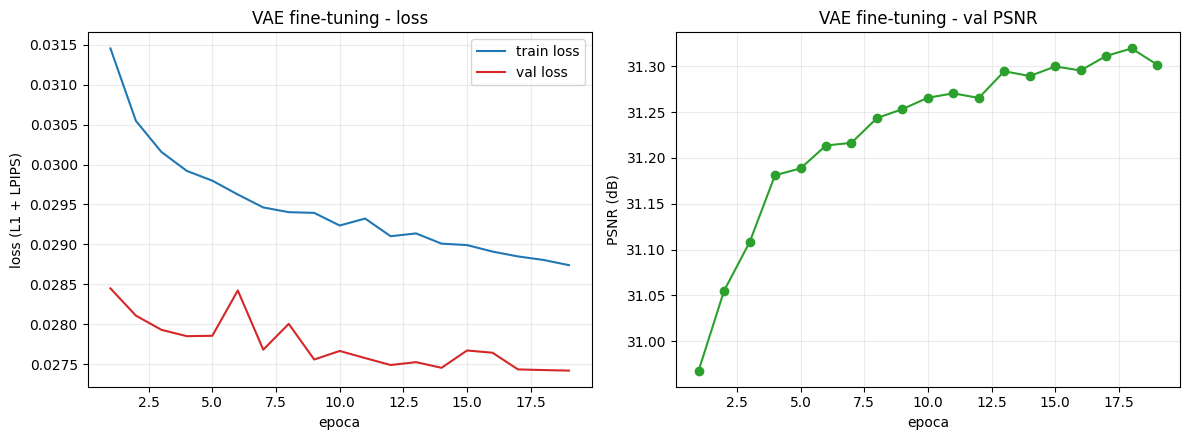

History VAE salvata in: /mnt/MammoDiffusion/MammoDiffusion/results/03c_finetuning_vae_adapted/plots/vae_finetuning/vae_finetuning_history.png
Log stdout VAE: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/vae_finetuning/vae_finetuning_stdout.log
Riepilogo best VAE:
{
  "best_epoch": 14,
  "best_val_loss": 0.027456,
  "best_val_psnr": 31.2893,
  "global_step": 10710,
  "wall_time_s": 24324.53,
  "stopped_early": true,
  "pretrained_model_dir": "/mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/pretrained_model/stable-diffusion-2-1-base",
  "output_dir": "/mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/vae_finetuning",
  "completed_epochs": 19
}


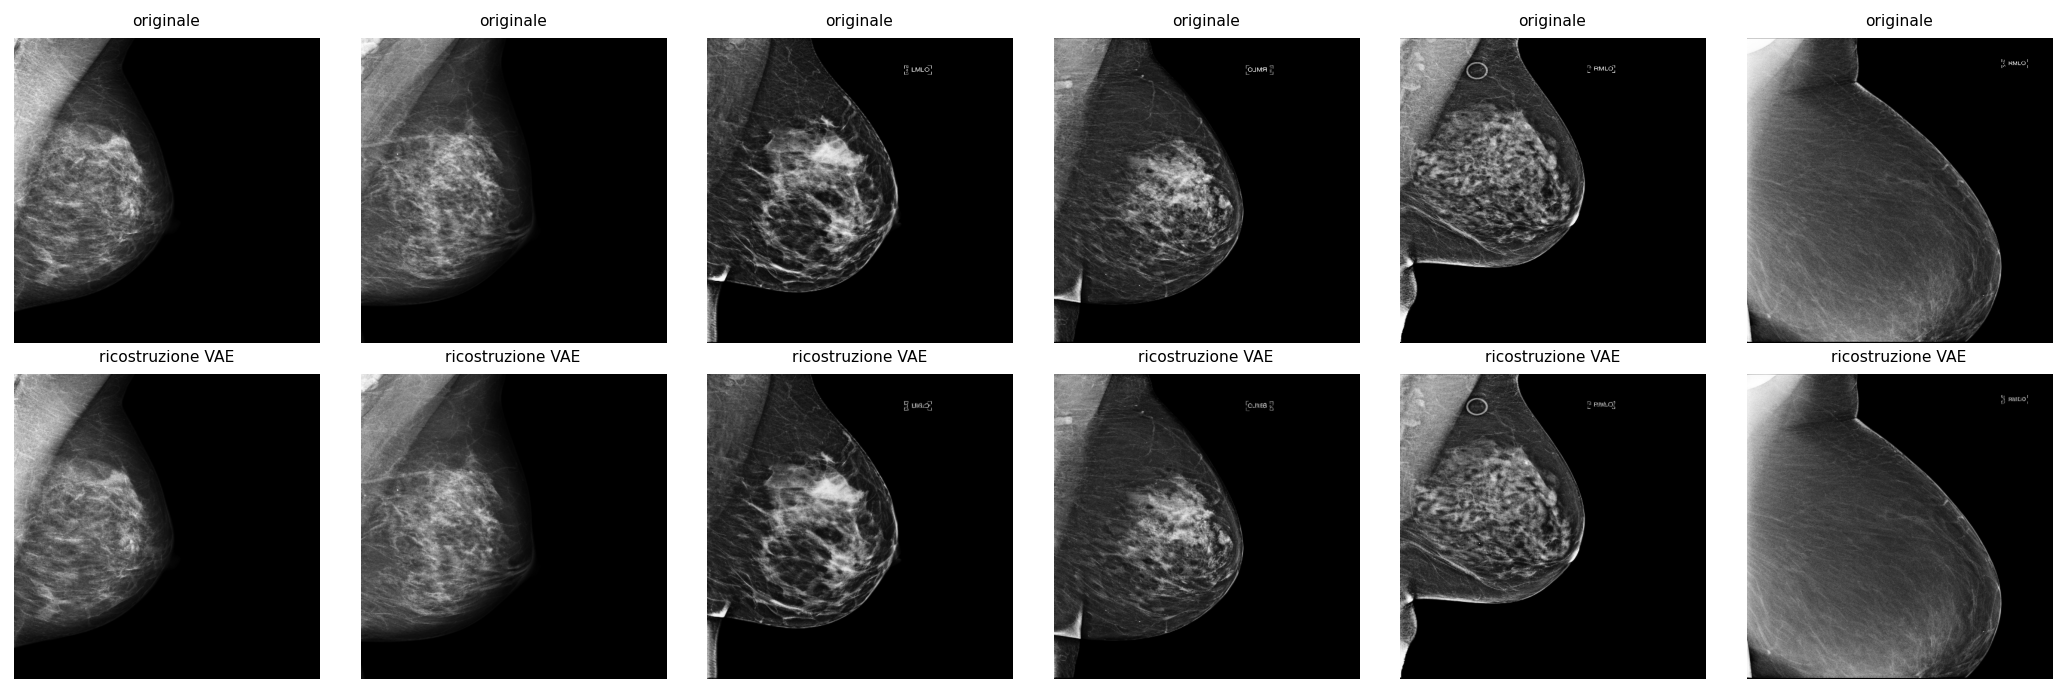

Griglia salvata anche in: /mnt/MammoDiffusion/MammoDiffusion/results/03c_finetuning_vae_adapted/plots/vae_finetuning/vae_reconstruction_before_training.png


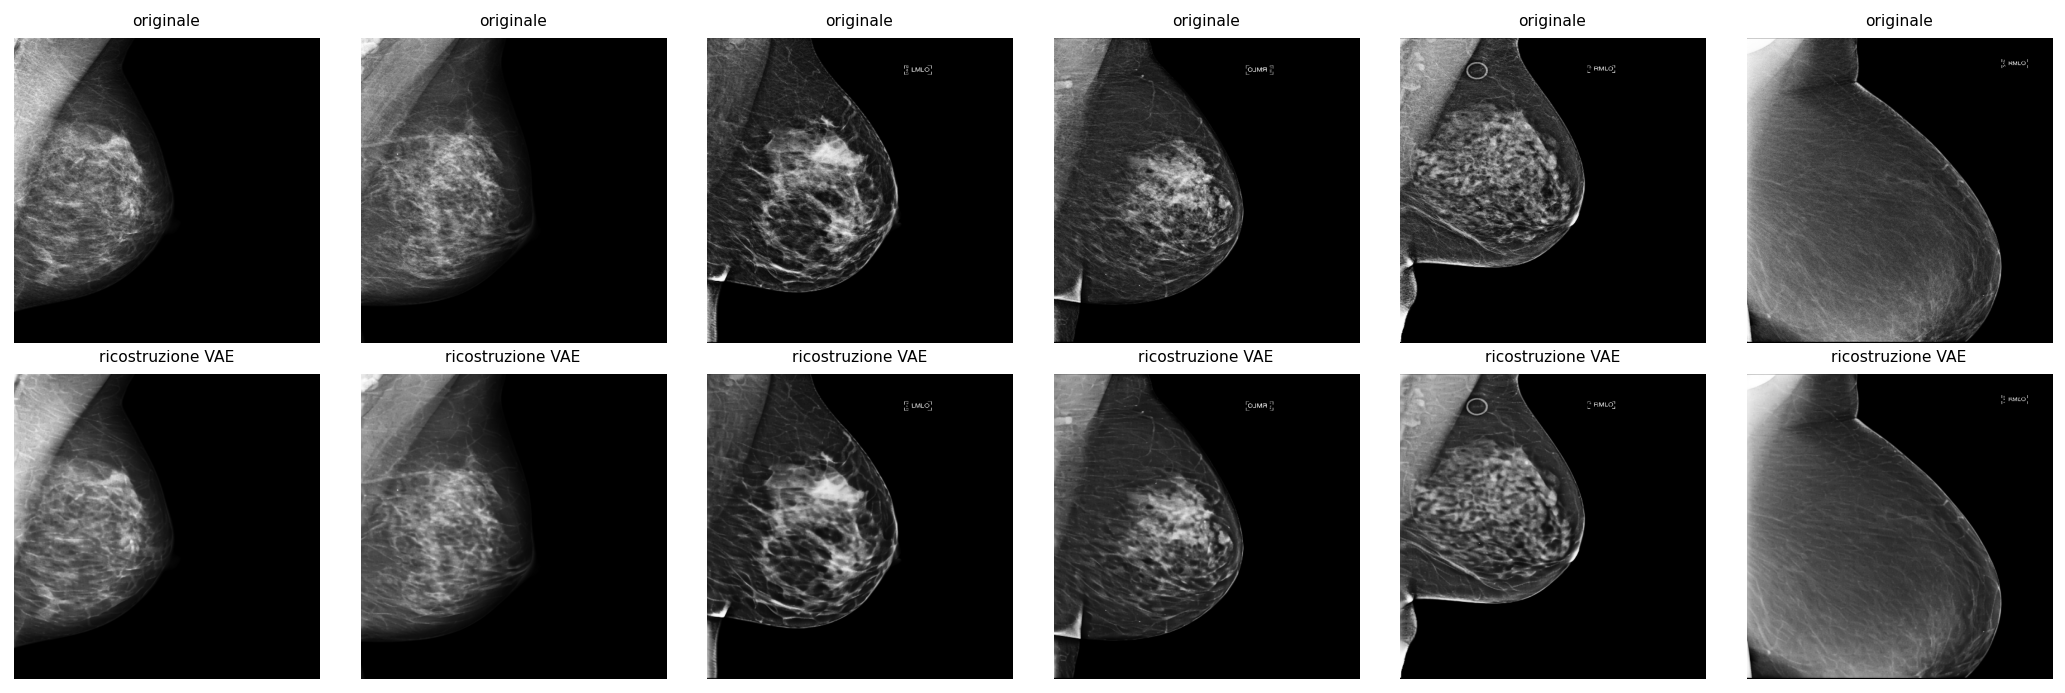

Griglia salvata anche in: /mnt/MammoDiffusion/MammoDiffusion/results/03c_finetuning_vae_adapted/plots/vae_finetuning/vae_reconstruction_before_after.png


In [6]:
# Diagnostica VAE fine-tuning: curva di loss + PSNR e riepilogo epoca migliore
if vae_history_csv.is_file():
    vae_history = pd.read_csv(vae_history_csv)
    fig, (ax_loss, ax_psnr) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax_loss.plot(vae_history["epoch"], vae_history["train_loss"], label="train loss", color="#1f77b4")
    ax_loss.plot(vae_history["epoch"], vae_history["val_loss"], label="val loss", color="#d62728")
    ax_loss.set(title="VAE fine-tuning - loss", xlabel="epoca", ylabel="loss (L1 + LPIPS)")
    ax_loss.grid(alpha=0.25); ax_loss.legend()
    ax_psnr.plot(vae_history["epoch"], vae_history["val_psnr"], color="#2ca02c", marker="o")
    ax_psnr.set(title="VAE fine-tuning - val PSNR", xlabel="epoca", ylabel="PSNR (dB)")
    ax_psnr.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(VAE_PLOTS_DIR / "vae_finetuning_history.png", dpi=160, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("History VAE salvata in:", VAE_PLOTS_DIR / "vae_finetuning_history.png")
    print("Log stdout VAE:", vae_stdout_log)
else:
    print("History del VAE non disponibile (training skippato o log assente).")

if vae_best_metrics_json.is_file():
    with vae_best_metrics_json.open(encoding="utf-8") as handle:
        vae_best = json.load(handle)
    print("Riepilogo best VAE:")
    print(json.dumps({key: vae_best[key] for key in vae_best if key != "args"}, indent=2, ensure_ascii=False))

for image_name in ["vae_reconstruction_before_training.png", "vae_reconstruction_before_after.png"]:
    source_path = vae_output_dir / image_name
    if not source_path.is_file():
        continue
    target_path = VAE_PLOTS_DIR / image_name
    if not target_path.is_file():
        shutil.copy2(source_path, target_path)
    with Image.open(source_path) as img:
        display(img.copy())
    print("Griglia salvata anche in:", target_path)

## 5. Costruzione del modello base con VAE adattato

Il modello SD2.1 originale non viene modificato. Viene invece creata una copia dedicata `pretrained_model_vaeft/stable-diffusion-2-1-base/` in cui la sotto-cartella `vae/` viene sostituita dal VAE fine-tuned. Questa cartella diventa il nuovo `--pretrained_model_name_or_path` per lo script di fine-tuning della U-Net, mantenendo intatto il modello sorgente.

In [7]:
def build_model_with_finetuned_vae(source_dir: Path, target_dir: Path, vae_source: Path) -> Path:
    source_dir = Path(source_dir).resolve()
    target_dir = Path(target_dir).resolve()
    vae_source = Path(vae_source).resolve()
    if target_dir.exists():
        shutil.rmtree(target_dir)
    shutil.copytree(source_dir, target_dir)
    # Sovrascrive esclusivamente la sotto-cartella vae/
    target_vae_dir = target_dir / "vae"
    if target_vae_dir.exists():
        shutil.rmtree(target_vae_dir)
    shutil.copytree(vae_source, target_vae_dir)
    create_model_weight_copies(target_dir)
    if not local_sd_model_ready(target_dir):
        raise RuntimeError(f"Modello SD2.1 con VAE fine-tuned incompleto: {target_dir}")
    return target_dir


LOCAL_MODEL_VAEFT_DIR = build_model_with_finetuned_vae(
    source_dir=LOCAL_MODEL_DIR,
    target_dir=PRETRAINED_MODEL_VAEFT_DIR,
    vae_source=vae_ft_weights_dir,
)
print("Nuovo modello base per la U-Net (VAE fine-tuned):", LOCAL_MODEL_VAEFT_DIR)

Nuovo modello base per la U-Net (VAE fine-tuned): /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/pretrained_model_vaeft/stable-diffusion-2-1-base


## 6. Fine-tuning della U-Net (stadio 2)

Il training della U-Net segue esattamente la stessa procedura di `03b`: precisione FP16, gradient accumulation, gradient checkpointing, 8-bit Adam, resume automatico su `latest`. Le uniche differenze sono:

- `--pretrained_model_name_or_path` punta a `pretrained_model_vaeft/stable-diffusion-2-1-base/`, dove il VAE e' quello adattato;
- `MAX_TRAIN_STEPS = 12000` (invece di 8000);
- `CHECKPOINTING_STEPS = 250` (invece di 500), con `CHECKPOINTS_TOTAL_LIMIT = 60`.

Nota: durante il training il VAE resta congelato (impostazione standard di `train_text_to_image.py`), quindi il fine-tuning riguarda esclusivamente la U-Net; il VAE fine-tuned entra in gioco come **decoder** delle latenti e influenza l'obiettivo di ricostruzione via feature encoder.

In [8]:
def build_training_command(train_data_dir):
    command = [
        sys.executable, "-m", "accelerate.commands.launch",
        "--mixed_precision=fp16",
        "--num_processes=1",
        str(TRAIN_SCRIPT),
        "--pretrained_model_name_or_path", str(LOCAL_MODEL_VAEFT_DIR),
        "--train_data_dir", str(train_data_dir),
        "--image_column", "image",
        "--caption_column", "text",
        "--resolution", str(RESOLUTION),
        "--center_crop",
        "--train_batch_size", str(TRAIN_BATCH_SIZE),
        "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
        "--gradient_checkpointing",
        "--max_train_steps", str(MAX_TRAIN_STEPS),
        "--learning_rate", str(LEARNING_RATE),
        "--lr_scheduler", "constant",
        "--lr_warmup_steps", "0",
        "--max_grad_norm", "1",
        "--use_8bit_adam",
        "--checkpointing_steps", str(CHECKPOINTING_STEPS),
        "--checkpoints_total_limit", str(CHECKPOINTS_TOTAL_LIMIT),
        "--validation_prompts", POSITIVE_PROMPT, NEGATIVE_PROMPT,
        "--validation_epochs", "2",
        "--seed", str(TRAIN_SEED),
        "--cache_dir", str(HF_CACHE_DIR),
        "--output_dir", str(SD_OUTPUT_DIR),
        "--report_to", "tensorboard",
        "--logging_dir", str(SD_OUTPUT_DIR / "logs"),
        "--dataloader_num_workers", "0",
    ]
    if RESUME_FROM_CHECKPOINT is not None:
        command.extend(["--resume_from_checkpoint", RESUME_FROM_CHECKPOINT])
    return command


def build_training_environment():
    environment = os.environ.copy()
    environment["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    conda_prefix = Path(sys.prefix)
    cuda_lib_paths = [
        conda_prefix / "lib",
        conda_prefix / "targets" / "x86_64-linux" / "lib",
        conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "cu13" / "lib",
        conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "nvjitlink" / "lib",
    ]
    existing = environment.get("LD_LIBRARY_PATH", "")
    environment["LD_LIBRARY_PATH"] = ":".join(
        [str(path) for path in cuda_lib_paths if path.exists()] + [existing]
    )
    return environment


run_label = f"finetune_sd21_vaeft_to_{MAX_TRAIN_STEPS}_steps"
if RESUME_FROM_CHECKPOINT is not None:
    run_label += f"_resume_{RESUME_FROM_CHECKPOINT}"
temporary_training = TemporaryDirectory(prefix="mammo_sd21_vaeft_train_copy_")
try:
    temporary_train_dir = Path(temporary_training.name)
    staged_metadata = stage_training_dataset(metadata_df, temporary_train_dir)
    command = build_training_command(temporary_train_dir)
    print("Staging temporaneo:", temporary_train_dir)
    print("Campioni copiati:", len(staged_metadata))
    print("Comando fine-tuning U-Net:\n", " ".join(map(str, command)))
    with measure_sustainability(label=run_label, sample_interval=0.5) as eco:
        process = subprocess.Popen(
            command,
            env=build_training_environment(),
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
            text=True, bufsize=1,
        )
        for line in iter(process.stdout.readline, ""):
            print(line, end="", flush=True)
        process.wait()
finally:
    temporary_training.cleanup()
    print("Staging temporaneo eliminato.")

record = eco.metrics.to_dict()
record.update({
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "stage": "unet_finetuning_over_vaeft",
    "max_train_steps": MAX_TRAIN_STEPS,
    "checkpointing_steps": CHECKPOINTING_STEPS,
    "resume_from_checkpoint": RESUME_FROM_CHECKPOINT,
    "resolution": RESOLUTION,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "source_metadata": str(DATA_AUG / "metadata.csv"),
    "pretrained_model_dir": str(LOCAL_MODEL_VAEFT_DIR),
    "vae_finetuned_dir": str(vae_ft_weights_dir),
    "output_dir": str(SD_OUTPUT_DIR),
    "returncode": process.returncode,
    "status": "completed" if process.returncode == 0 else "failed",
})
with SUSTAINABILITY_LOG.open("a", encoding="utf-8") as handle:
    handle.write(json.dumps(record, ensure_ascii=False) + "\n")
print("Metriche sostenibilita' U-Net:", eco.metrics)
if process.returncode != 0:
    raise subprocess.CalledProcessError(process.returncode, command)

[codecarbon WARNING @ 00:55:39] Multiple instances of codecarbon are allowed to run at the same time.


Staging temporaneo: /tmp/mammo_sd21_vaeft_train_copy_mtokenjy
Campioni copiati: 3061
Comando fine-tuning U-Net:
 /home/fede/miniforge3/envs/tf-gpu/bin/python -m accelerate.commands.launch --mixed_precision=fp16 --num_processes=1 /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/diffusers_repo/examples/text_to_image/train_text_to_image.py --pretrained_model_name_or_path /mnt/MammoDiffusion/MammoDiffusion/experiments/20260706_sd21_vaeft_extra1361/pretrained_model_vaeft/stable-diffusion-2-1-base --train_data_dir /tmp/mammo_sd21_vaeft_train_copy_mtokenjy --image_column image --caption_column text --resolution 512 --center_crop --train_batch_size 2 --gradient_accumulation_steps 4 --gradient_checkpointing --max_train_steps 12000 --learning_rate 1e-05 --lr_scheduler constant --lr_warmup_steps 0 --max_grad_norm 1 --use_8bit_adam --checkpointing_steps 250 --checkpoints_total_limit 60 --validation_prompts grayscale MLO mammogram, breast cancer positive, malignant findi

## 7. Valutazione, generazione, filtro e test

Le fasi successive sono identiche per struttura a quelle di `03b`, cambiano solo:

- il modello base (`LOCAL_MODEL_VAEFT_DIR`);
- le cartelle di output (`EXPERIMENT_DIR`, `RESULTS_03C_DIR`, `SYNTHETIC_VAEFT_DIR`);
- il maggior numero di checkpoint disponibili in valutazione, prodotti da `CHECKPOINTING_STEPS=250`.

Per non duplicare centinaia di righe, questa sezione **importa dinamicamente le stesse celle utility del notebook `03b`** (funzioni `discover_checkpoints`, `load_pipeline_from_checkpoint`, `eval_one_checkpoint`, `evaluate_generated_dir_against_split`, ecc.) direttamente dal file `.ipynb` gia' presente in `notebooks/`, senza dover riscrivere il codice.

**Metodo di import:** viene aperto `02_SD21_Filtered_100steps.ipynb`, estratte le celle di codice dalle sezioni 5-9 e definite come funzioni nel namespace corrente. Se il file non e' disponibile, ricadere sulla riscrittura manuale.

Le variabili puntano gia' alle nuove cartelle 03c, quindi non c'e' contaminazione con gli artefatti di `03b`.

In [ ]:
# Import dinamico delle utility valutazione/generazione/filtro/test da 03b.
# Le variabili di configurazione 03c (SD_OUTPUT_DIR, FINAL_DIRS, ecc.) restano quelle definite sopra:
# le funzioni le leggono dal namespace globale, quindi punteranno automaticamente ai path 03c.

NB03B_PATH = NOTEBOOKS_DIR / "02_SD21_Filtered_100steps.ipynb"
if not NB03B_PATH.is_file():
    raise FileNotFoundError(
        f"Notebook 03b non trovato in {NB03B_PATH}. "
        "Per eseguire 03c e' necessaria la presenza delle utility di 03b nella stessa cartella."
    )

with NB03B_PATH.open(encoding="utf-8") as handle:
    nb03b_payload = json.load(handle)

# Estrae solo le celle di codice a partire dalla sezione 5 di 03b (valutazione checkpoint), che
# introduce la logica per generazione, filtro e test. Le celle 3-11 di 03b (bootstrap, dataset,
# modello base, training) sono gia' state ricoperte da 03c con la variante VAE-adattato.
cells_to_reuse = []
in_reuse_zone = False
for cell in nb03b_payload["cells"]:
    source = "".join(cell["source"]) if isinstance(cell["source"], list) else cell["source"]
    if cell["cell_type"] == "markdown" and source.strip().startswith("## 5."):
        in_reuse_zone = True
        continue
    if not in_reuse_zone:
        continue
    if cell["cell_type"] != "code":
        continue
    cells_to_reuse.append(source)

# Filtra le celle di 03b che referenziano variabili 03b-only:
# - RESULTS_03B_DIR / EXPERIMENT_50_DIR: cella finale di 03b (confronto 50 vs 100 step +
#   artifacts manifest 03b-specifico); in 03c abbiamo la sezione 8 dedicata (confronto
#   03b vs 03c) e non serve replicare il confronto 50-vs-100 di 03b.
_skip_refs = ("RESULTS_03B_DIR", "EXPERIMENT_50_DIR")
cells_to_reuse = [source for source in cells_to_reuse if not any(ref in source for ref in _skip_refs)]

print(f"Celle di codice riutilizzate da 03b: {len(cells_to_reuse)}")

# CORREZIONE: le funzioni riusate da 03b (eval_one_checkpoint, load_pipeline_from_checkpoint)
# leggono `LOCAL_MODEL_DIR` come base_model_dir per il pipeline di generazione/valutazione.
# In questo notebook pero' `LOCAL_MODEL_DIR` (cella 3) resta l'SD2.1 ORIGINALE: non viene mai
# riassegnato al modello con VAE adattato `LOCAL_MODEL_VAEFT_DIR` (costruito nella sezione 5,
# usato finora solo per il training della U-Net). Senza questa riassegnazione, la valutazione
# checkpoint e la generazione finale userebbero il decoder VAE NON adattato, vanificando il
# fine-tuning del VAE che e' il punto centrale di questo notebook. Da qui in poi, le funzioni
# riusate da 03b useranno quindi il modello con VAE adattato.
LOCAL_MODEL_DIR = LOCAL_MODEL_VAEFT_DIR

# Esegui una per una in modo controllato, forwardando i print nel notebook.
for index, source in enumerate(cells_to_reuse, start=1):
    print(f"\n===== 03b cell #{index} =====")
    exec(compile(source, f"<03b_cell_{index}>", "exec"), globals())


## 8. Confronto 03b (VAE congelato) vs 03c (VAE adattato)

Questa sezione confronta i risultati finali di `03b` e `03c` sullo stesso test set reale, usando esclusivamente artefatti gia' salvati. Nessuna metrica viene ricalcolata: si legge `results/diffusers/02_sd21_filtered_100steps/metrics/final_test_metrics.json` e l'analogo in `results/diffusers/03_sd21_vae_finetuned/metrics/final_test_metrics.json`.

Vengono prodotti:

- un CSV riepilogativo (`comparison_03b_vs_03c.csv`);
- un grafico a barre per FID, IS, precision, recall, density, coverage per classe;
- una tabella dei delta percentuali (03c rispetto a 03b), con orientamento coerente al miglioramento.

In [ ]:
RESULTS_03B_DIR = RESULTS_DIR / "diffusers/02_sd21_filtered_100steps"
final_test_03b_path = RESULTS_03B_DIR / "metrics" / "final_test_metrics.json"
final_test_03c_path = FINAL_TEST_METRICS_PATH


def load_final_test_metrics(path, tag):
    if not Path(path).is_file():
        print(f"[{tag}] metriche finali test non disponibili: {path}")
        return None
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)


metrics_03b = load_final_test_metrics(final_test_03b_path, "03b")
metrics_03c = load_final_test_metrics(final_test_03c_path, "03c")

if metrics_03b is None or metrics_03c is None:
    print("Confronto 03b vs 03c non disponibile (metriche mancanti su almeno una pipeline).")
else:
    METRIC_ORDER = ["FID", "IS_mean", "precision", "recall", "density", "coverage"]
    LOWER_IS_BETTER = {"FID"}

    def rows_from(payload, tag):
        rows = []
        for class_name, metrics in payload.get("per_class", {}).items():
            if class_name == "average":
                continue
            row = {"pipeline": tag, "class": class_name}
            for metric in METRIC_ORDER:
                row[metric] = metrics.get(metric)
            rows.append(row)
        return rows

    df_compare = pd.DataFrame(rows_from(metrics_03b, "03b") + rows_from(metrics_03c, "03c"))
    compare_csv = METRICS_DIR / "comparison_03b_vs_03c.csv"
    df_compare.to_csv(compare_csv, index=False)
    print("Riepilogo salvato in:", compare_csv)
    print(df_compare.to_string(index=False))

    delta_rows = []
    for class_name in df_compare["class"].unique():
        row_03b = df_compare[(df_compare["pipeline"] == "03b") & (df_compare["class"] == class_name)]
        row_03c = df_compare[(df_compare["pipeline"] == "03c") & (df_compare["class"] == class_name)]
        if row_03b.empty or row_03c.empty:
            continue
        entry = {"class": class_name}
        for metric in METRIC_ORDER:
            baseline = row_03b.iloc[0][metric]
            candidate = row_03c.iloc[0][metric]
            if baseline is None or candidate is None or pd.isna(baseline) or pd.isna(candidate) or baseline == 0:
                entry[f"{metric}_delta_pct"] = None
                continue
            delta = (candidate - baseline) / abs(baseline) * 100.0
            if metric in LOWER_IS_BETTER:
                delta = -delta  # orienta al miglioramento (positivo = meglio)
            entry[f"{metric}_delta_pct"] = round(float(delta), 2)
        delta_rows.append(entry)
    df_delta = pd.DataFrame(delta_rows)
    delta_csv = METRICS_DIR / "comparison_03b_vs_03c_delta_percent.csv"
    df_delta.to_csv(delta_csv, index=False)
    print("\nDelta % orientati al miglioramento (positivo = 03c meglio di 03b):")
    print(df_delta.to_string(index=False))
    print("Salvato in:", delta_csv)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, metric in zip(axes.flat, METRIC_ORDER):
        pivot = df_compare.pivot(index="class", columns="pipeline", values=metric)
        pivot.plot.bar(ax=ax, color=["#4C78A8", "#F58518"])
        ax.set_title(f"{metric} sul test - 03b vs 03c")
        ax.set_ylabel(metric)
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(title="pipeline")
    fig.tight_layout()
    plot_path = PLOTS_DIR / "comparison_03b_vs_03c_test_metrics.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("Grafico salvato in:", plot_path)